In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# Load Data

In [4]:
#DATASET_DIR = "/kaggle/input"
DATASET_DIR = "./dataset"

def find_file(filename):
    for root, _, files in os.walk(DATASET_DIR):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(filename)

#hrv = pd.read_csv(find_file("sensor_hrv_filtered.csv"))
#sleep = pd.read_csv(find_file("sleep_diary.csv"))
#survey = pd.read_csv(find_file("survey.csv"))
hrv = pd.read_csv("dataset/sensor_hrv.csv")
sleep = pd.read_csv("dataset/sleep_diary.csv")
survey = pd.read_csv("dataset/survey.csv")

print(hrv.shape, sleep.shape, survey.shape)

(79639, 28) (1372, 11) (49, 23)


# HRV Processing

In [5]:
# Create date from millisecond timestamp
hrv['date'] = pd.to_datetime(hrv['ts_start'], unit='ms').dt.date

hrv_daily = hrv.groupby(['deviceId', 'date']).agg({
    'rmssd': 'mean',
    'sdnn': 'mean',
    'sdsd': 'mean',
    'pnn20': 'mean',
    'pnn50': 'mean',
    'lf': 'mean',
    'hf': 'mean',
    'lf/hf': 'mean',
    'HR': 'mean',
    'missingness_score': 'mean',
    'steps': 'sum',
    'distance': 'sum',
    'calories': 'sum',
    'light_avg': 'mean'
}).reset_index()

hrv_daily.head()

,deviceId,date,rmssd,sdnn,sdsd,pnn20,pnn50,lf,hf,lf/hf,HR,missingness_score,steps,distance,calories,light_avg
0,ab60,2021-03-04,90.862295,89.532895,57.242131,0.727249,0.424528,1748.634946,2610.122096,0.991055,85.236284,0.336169,0.000000,0.000000,0.000000,444.605828
1,ab60,2021-03-08,102.761346,98.825747,71.867749,0.707074,0.391947,2355.004408,6862.890031,1.125409,88.942591,0.452435,245.967172,191.219839,8.515090,366.824818
2,ab60,2021-03-09,78.634204,80.246911,54.147800,0.632927,0.322495,1549.223732,2455.860287,1.572463,91.478030,0.310058,169.650000,130.736084,6.163652,606.479150
3,ab60,2021-03-10,94.785097,93.683138,69.949817,0.637689,0.358431,2396.157199,5669.999522,1.059661,97.571103,0.438396,431.199134,332.645582,15.559575,192.760274
4,ab60,2021-03-11,97.480428,92.788597,67.889261,0.699205,0.399301,2035.593647,3249.881126,1.041845,91.513055,0.354561,210.080952,158.908455,7.607583,299.288603


# Sleep Feature Engineering

In [6]:
# ===============================
# PART 3 — Sleep Feature Engineering (FINAL FIX)
# ===============================

# Align identifier name
sleep = sleep.rename(columns={'userId': 'deviceId'})

# Ensure date format
sleep['date'] = pd.to_datetime(sleep['date']).dt.date

# ---- CREATE sleep_duration_hours (THIS WAS MISSING) ----
# sleep_duration is assumed to be in minutes
sleep['sleep_duration_hours'] = sleep['sleep_duration'] / 60.0

# Aggregate PER USER PER DAY
sleep_features = sleep.groupby(['deviceId', 'date']).agg({
    'sleep_duration_hours': 'mean',
    'sleep_efficiency': 'mean',
    'sleep_latency': 'mean',
    'waso': 'mean',
    'in_bed_duration': 'mean'
}).reset_index()

sleep_features.head()

,deviceId,date,sleep_duration_hours,sleep_efficiency,sleep_latency,waso,in_bed_duration
0,ab60,2021-03-09,0.141667,0.944444,0.500000,0.0,9.000000
1,ab60,2021-03-10,0.113889,0.911111,0.666667,0.0,7.500000
2,ab60,2021-03-11,0.150000,0.947368,0.500000,30.0,9.500000
3,ab60,2021-03-12,0.152778,0.948276,0.500000,0.0,9.666667
4,ab60,2021-03-13,0.143056,0.980952,0.166667,0.0,8.750000


# Survey → Stress Labels

In [7]:
# Moderate-to-severe anxiety as stress
survey['stress_label'] = (survey['GAD7_F'] >= 10).astype(int)

stress_labels = survey[['deviceId', 'stress_label']]
stress_labels.head()

,deviceId,stress_label
0,pm96,0
1,vc10,0
2,pg18,0
3,nd56,0
4,vs14,0


# Final Merge

In [8]:
# Daily HRV + Sleep
df = hrv_daily.merge(
    sleep_features,
    on=['deviceId', 'date'],
    how='inner'
)

# Add user-level stress labels
df = df.merge(
    stress_labels,
    on='deviceId',
    how='left'
)

print(df.shape)
df.head()

(1274, 22)


,deviceId,date,rmssd,sdnn,sdsd,pnn20,pnn50,lf,hf,lf/hf,...,steps,distance,calories,light_avg,sleep_duration_hours,sleep_efficiency,sleep_latency,waso,in_bed_duration,stress_label
0,ab60,2021-03-09,78.634204,80.246911,54.147800,0.632927,0.322495,1.549224e+03,2.455860e+03,1.572463,...,169.650000,130.736084,6.163652,606.479150,0.141667,0.944444,0.500000,0.0,9.000000,0
1,ab60,2021-03-10,94.785097,93.683138,69.949817,0.637689,0.358431,2.396157e+03,5.670000e+03,1.059661,...,431.199134,332.645582,15.559575,192.760274,0.113889,0.911111,0.666667,0.0,7.500000,0
2,ab60,2021-03-11,97.480428,92.788597,67.889261,0.699205,0.399301,2.035594e+03,3.249881e+03,1.041845,...,210.080952,158.908455,7.607583,299.288603,0.150000,0.947368,0.500000,30.0,9.500000,0
3,ab60,2021-03-12,107.111586,100.260690,73.638222,0.751803,0.475679,1.747488e+08,2.192316e+08,0.806823,...,121.016667,92.648703,4.355538,283.055100,0.152778,0.948276,0.500000,0.0,9.666667,0
4,ab60,2021-03-13,95.653282,88.798919,67.401023,0.677090,0.370051,1.656277e+03,3.513008e+03,1.261171,...,26.500000,21.345703,1.025086,154.187053,0.143056,0.980952,0.166667,0.0,8.750000,0


# Exploratory Data Analysis

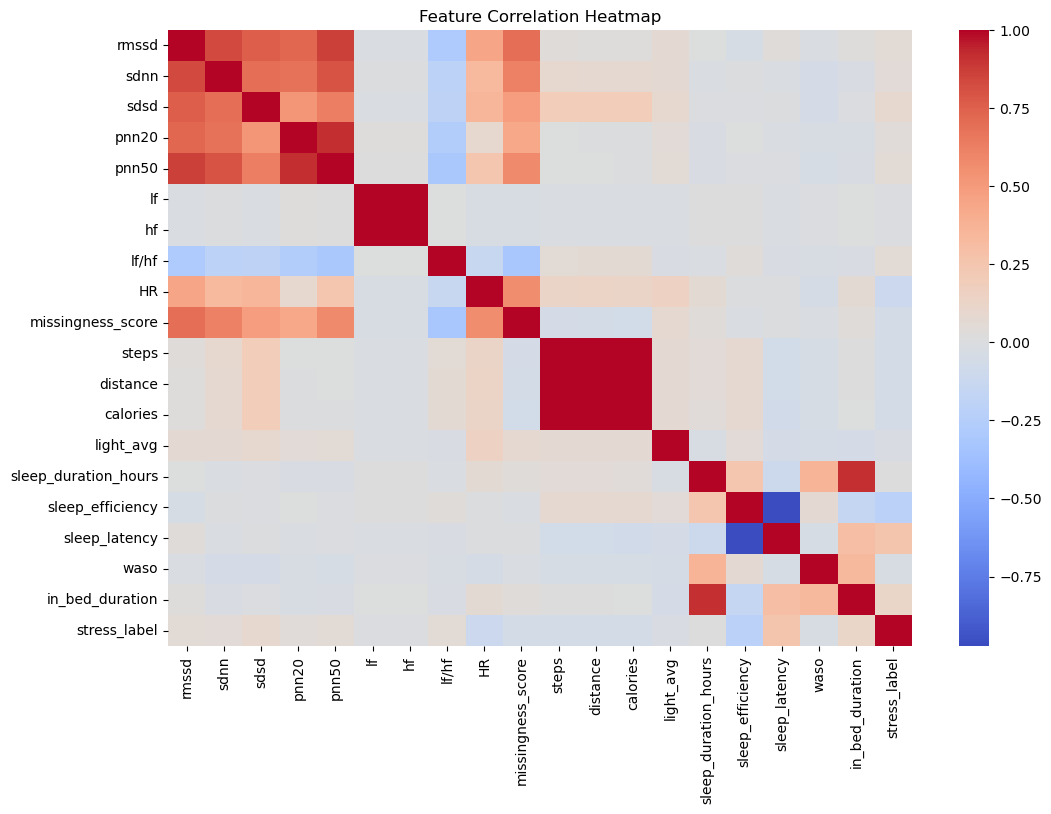

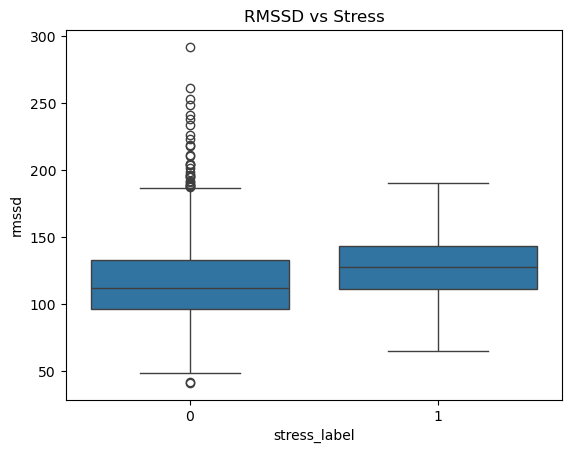

In [9]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
sns.boxplot(x='stress_label', y='rmssd', data=df)
plt.title("RMSSD vs Stress")
plt.show()

# ML Dataset Preparation

In [10]:
y = df['stress_label']

X = df.drop(columns=['deviceId', 'date', 'stress_label'])
X = X.select_dtypes(include=[np.number])

print(X.shape)

(1274, 19)


# Preprocessing Pipeline

In [11]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_processed = pipeline.fit_transform(X)

# Stress Classification Model

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       251
           1       0.00      0.00      0.00         4

    accuracy                           0.98       255
   macro avg       0.49      0.50      0.50       255
weighted avg       0.97      0.98      0.98       255



# ROC-AUC Evaluation

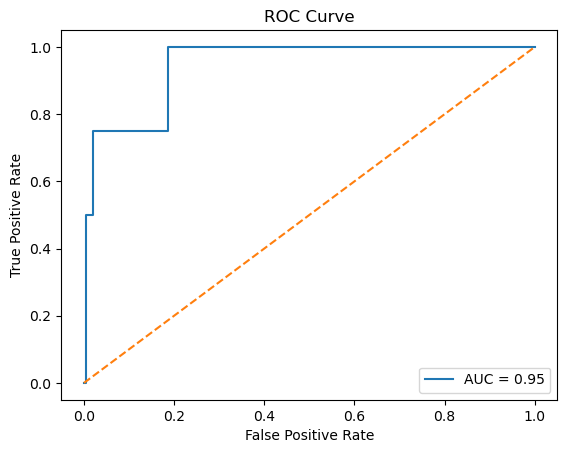

In [13]:
y_prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance

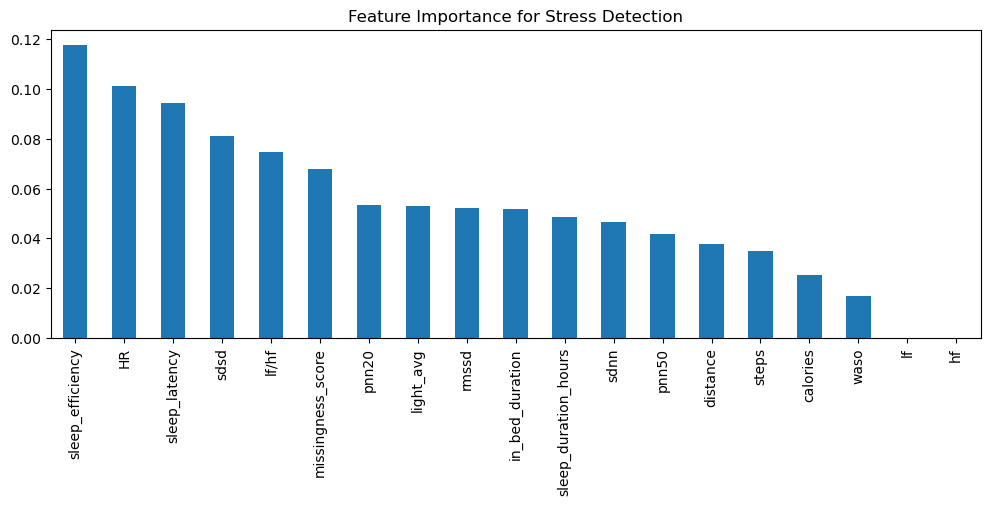

In [14]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind='bar', figsize=(12,4))
plt.title("Feature Importance for Stress Detection")
plt.show()

# Save Final Output

In [15]:
df.to_csv("/kaggle/working/final_stress_dataset.csv", index=False)

OSError: Cannot save file into a non-existent directory: '\kaggle\working'